# Gender 0:Female, 1:Male 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
churn_data = pd.read_csv('Customer-Churn-Records.csv')

In [4]:
df = churn_data.copy()

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [7]:
print(f'Categorical Type: {df.select_dtypes(include='object').columns}')
print(f'Total : {len(df.select_dtypes(include='object').columns)}')
print('\n')
print(f'Numerical Type: {df.select_dtypes(exclude='object').columns}')
print(f'Total : {len(df.select_dtypes(exclude='object').columns)}')


Categorical Type: Index(['Surname', 'Geography', 'Gender', 'Card Type'], dtype='object')
Total : 4


Numerical Type: Index(['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Complain', 'Satisfaction Score', 'Point Earned'],
      dtype='object')
Total : 14


In [8]:
drop_feature = ['Surname', 'RowNumber', 'CustomerId']
df = df.drop(drop_feature, axis=1)

In [9]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [10]:
categorical_col = df.select_dtypes(include='object').columns
numerical_col = df.select_dtypes(exclude='object').columns

for col in categorical_col:
    print(f'{col} : {df[col].unique()}')
    print(f'Total Unique of {col}: {df[col].nunique()}\n')

Geography : ['France' 'Spain' 'Germany']
Total Unique of Geography: 3

Gender : ['Female' 'Male']
Total Unique of Gender: 2

Card Type : ['DIAMOND' 'GOLD' 'SILVER' 'PLATINUM']
Total Unique of Card Type: 4



## One Hot Encoding

In [11]:
from sklearn.preprocessing import OneHotEncoder
ordinal_encoder = OrdinalEncoder()
oh_encoder = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
for col in categorical_col:
    if col == 'Gender':
        df[col] = ordinal_encoder.fit_transform(df[[col]])
    else:
        df = pd.concat([
            df.drop(col, axis=1),
            oh_encoder.fit_transform(df[[col]])
        ], axis=1)

In [12]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned,Geography_France,Geography_Germany,Geography_Spain,Card Type_DIAMOND,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,619,0.0,42,2,0.00,1,1,1,101348.88,1,1,2,464,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,608,0.0,41,1,83807.86,1,0,1,112542.58,0,1,3,456,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,502,0.0,42,8,159660.80,3,1,0,113931.57,1,1,3,377,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,699,0.0,39,1,0.00,2,0,0,93826.63,0,0,5,350,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,850,0.0,43,2,125510.82,1,1,1,79084.10,0,0,5,425,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [13]:
df.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'Satisfaction Score', 'Point Earned', 'Geography_France',
       'Geography_Germany', 'Geography_Spain', 'Card Type_DIAMOND',
       'Card Type_GOLD', 'Card Type_PLATINUM', 'Card Type_SILVER'],
      dtype='object')

In [14]:
feature = ['Geography_France',
       'Geography_Germany', 'Geography_Spain',
       'Card Type_DIAMOND', 'Card Type_GOLD', 'Card Type_PLATINUM',
       'Card Type_SILVER']


In [15]:
for col in feature:
    df[col] = df[col].astype('int64')

df['Gender'] = df['Gender'].astype('int64')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         10000 non-null  int64  
 1   Gender              10000 non-null  int64  
 2   Age                 10000 non-null  int64  
 3   Tenure              10000 non-null  int64  
 4   Balance             10000 non-null  float64
 5   NumOfProducts       10000 non-null  int64  
 6   HasCrCard           10000 non-null  int64  
 7   IsActiveMember      10000 non-null  int64  
 8   EstimatedSalary     10000 non-null  float64
 9   Exited              10000 non-null  int64  
 10  Complain            10000 non-null  int64  
 11  Satisfaction Score  10000 non-null  int64  
 12  Point Earned        10000 non-null  int64  
 13  Geography_France    10000 non-null  int64  
 14  Geography_Germany   10000 non-null  int64  
 15  Geography_Spain     10000 non-null  int64  
 16  Card 

In [17]:
df['Gender'].value_counts()

Gender
1    5457
0    4543
Name: count, dtype: int64

## Oversampling: SMOT

In [18]:
from imblearn.over_sampling import SMOTE
X = df.drop('Exited', axis=1)
y = df['Exited']

smote = SMOTE(random_state=0)
X_sample, y_sample = smote.fit_resample(X, y)


In [19]:
df2 = pd.DataFrame(X_sample, columns=df.drop('Exited', axis=1).columns)
df2['Exited'] = y_sample

In [20]:
df2.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Complain',
       'Satisfaction Score', 'Point Earned', 'Geography_France',
       'Geography_Germany', 'Geography_Spain', 'Card Type_DIAMOND',
       'Card Type_GOLD', 'Card Type_PLATINUM', 'Card Type_SILVER', 'Exited'],
      dtype='object')

In [21]:
df['Card Type_SILVER'].value_counts()

Card Type_SILVER
0    7504
1    2496
Name: count, dtype: int64

In [22]:
for i, col in enumerate(numerical_col):
    print(i, col)

0 CreditScore
1 Age
2 Tenure
3 Balance
4 NumOfProducts
5 HasCrCard
6 IsActiveMember
7 EstimatedSalary
8 Exited
9 Complain
10 Satisfaction Score
11 Point Earned


In [23]:
df2.corr()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Point Earned,Geography_France,Geography_Germany,Geography_Spain,Card Type_DIAMOND,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER,Exited
CreditScore,1.000000,0.001823,-0.015980,0.020774,0.008726,0.018274,-0.001804,0.024265,-0.024742,-0.041361,0.008556,0.006937,-0.004062,0.005331,0.014407,0.009284,0.014683,-0.001124,0.001454,-0.040670
Gender,0.001823,1.000000,-0.122137,0.038989,-0.018215,0.072304,0.082098,0.151162,-0.013013,-0.325115,0.065904,-0.014440,0.109911,-0.014674,0.095662,0.070597,0.112063,0.080031,0.076337,-0.325851
Age,-0.015980,-0.122137,1.000000,-0.039029,0.041211,-0.085155,-0.070830,-0.048233,-0.002495,0.357239,-0.052064,-0.000942,-0.101133,0.027683,-0.069203,-0.057456,-0.064885,-0.058973,-0.071889,0.358200
Tenure,0.020774,0.038989,-0.039029,1.000000,-0.002870,0.038492,0.031698,0.013063,0.022038,-0.074004,0.011393,-0.006705,0.025621,-0.000349,0.018116,0.017859,0.038601,0.008829,0.022189,-0.074180
Balance,0.008726,-0.018215,0.041211,-0.002870,1.000000,-0.233134,-0.026091,-0.042331,0.006638,0.136233,-0.022431,0.027589,-0.283692,0.364736,-0.152575,-0.001807,-0.027740,-0.027565,-0.026066,0.136639
NumOfProducts,0.018274,0.072304,-0.085155,0.038492,-0.233134,1.000000,0.047783,0.103962,0.016558,-0.213328,0.040433,-0.014609,0.085483,-0.018546,0.070643,0.042142,0.057690,0.077481,0.059663,-0.215073
HasCrCard,-0.001804,0.082098,-0.070830,0.031698,-0.026091,0.047783,1.000000,0.077749,-0.022067,-0.167840,0.025897,-0.023765,0.057064,0.007743,0.040395,0.051858,0.038988,0.059004,0.057856,-0.167680
IsActiveMember,0.024265,0.151162,-0.048233,0.013063,-0.042331,0.103962,0.077749,1.000000,-0.016140,-0.374871,0.065215,-0.009858,0.122615,-0.011415,0.105290,0.070090,0.102518,0.092404,0.100672,-0.377107
EstimatedSalary,-0.024742,-0.013013,-0.002495,0.022038,0.006638,0.016558,-0.022067,-0.016140,1.000000,0.012974,-0.003096,0.009740,0.001492,-0.009674,-0.005054,-0.006032,0.002481,-0.005942,0.014834,0.013369
Complain,-0.041361,-0.325115,0.357239,-0.074004,0.136233,-0.213328,-0.167840,-0.374871,0.012974,1.000000,-0.127278,-0.002382,-0.284369,0.088589,-0.219645,-0.163707,-0.200205,-0.183121,-0.183373,0.996609


<Axes: >

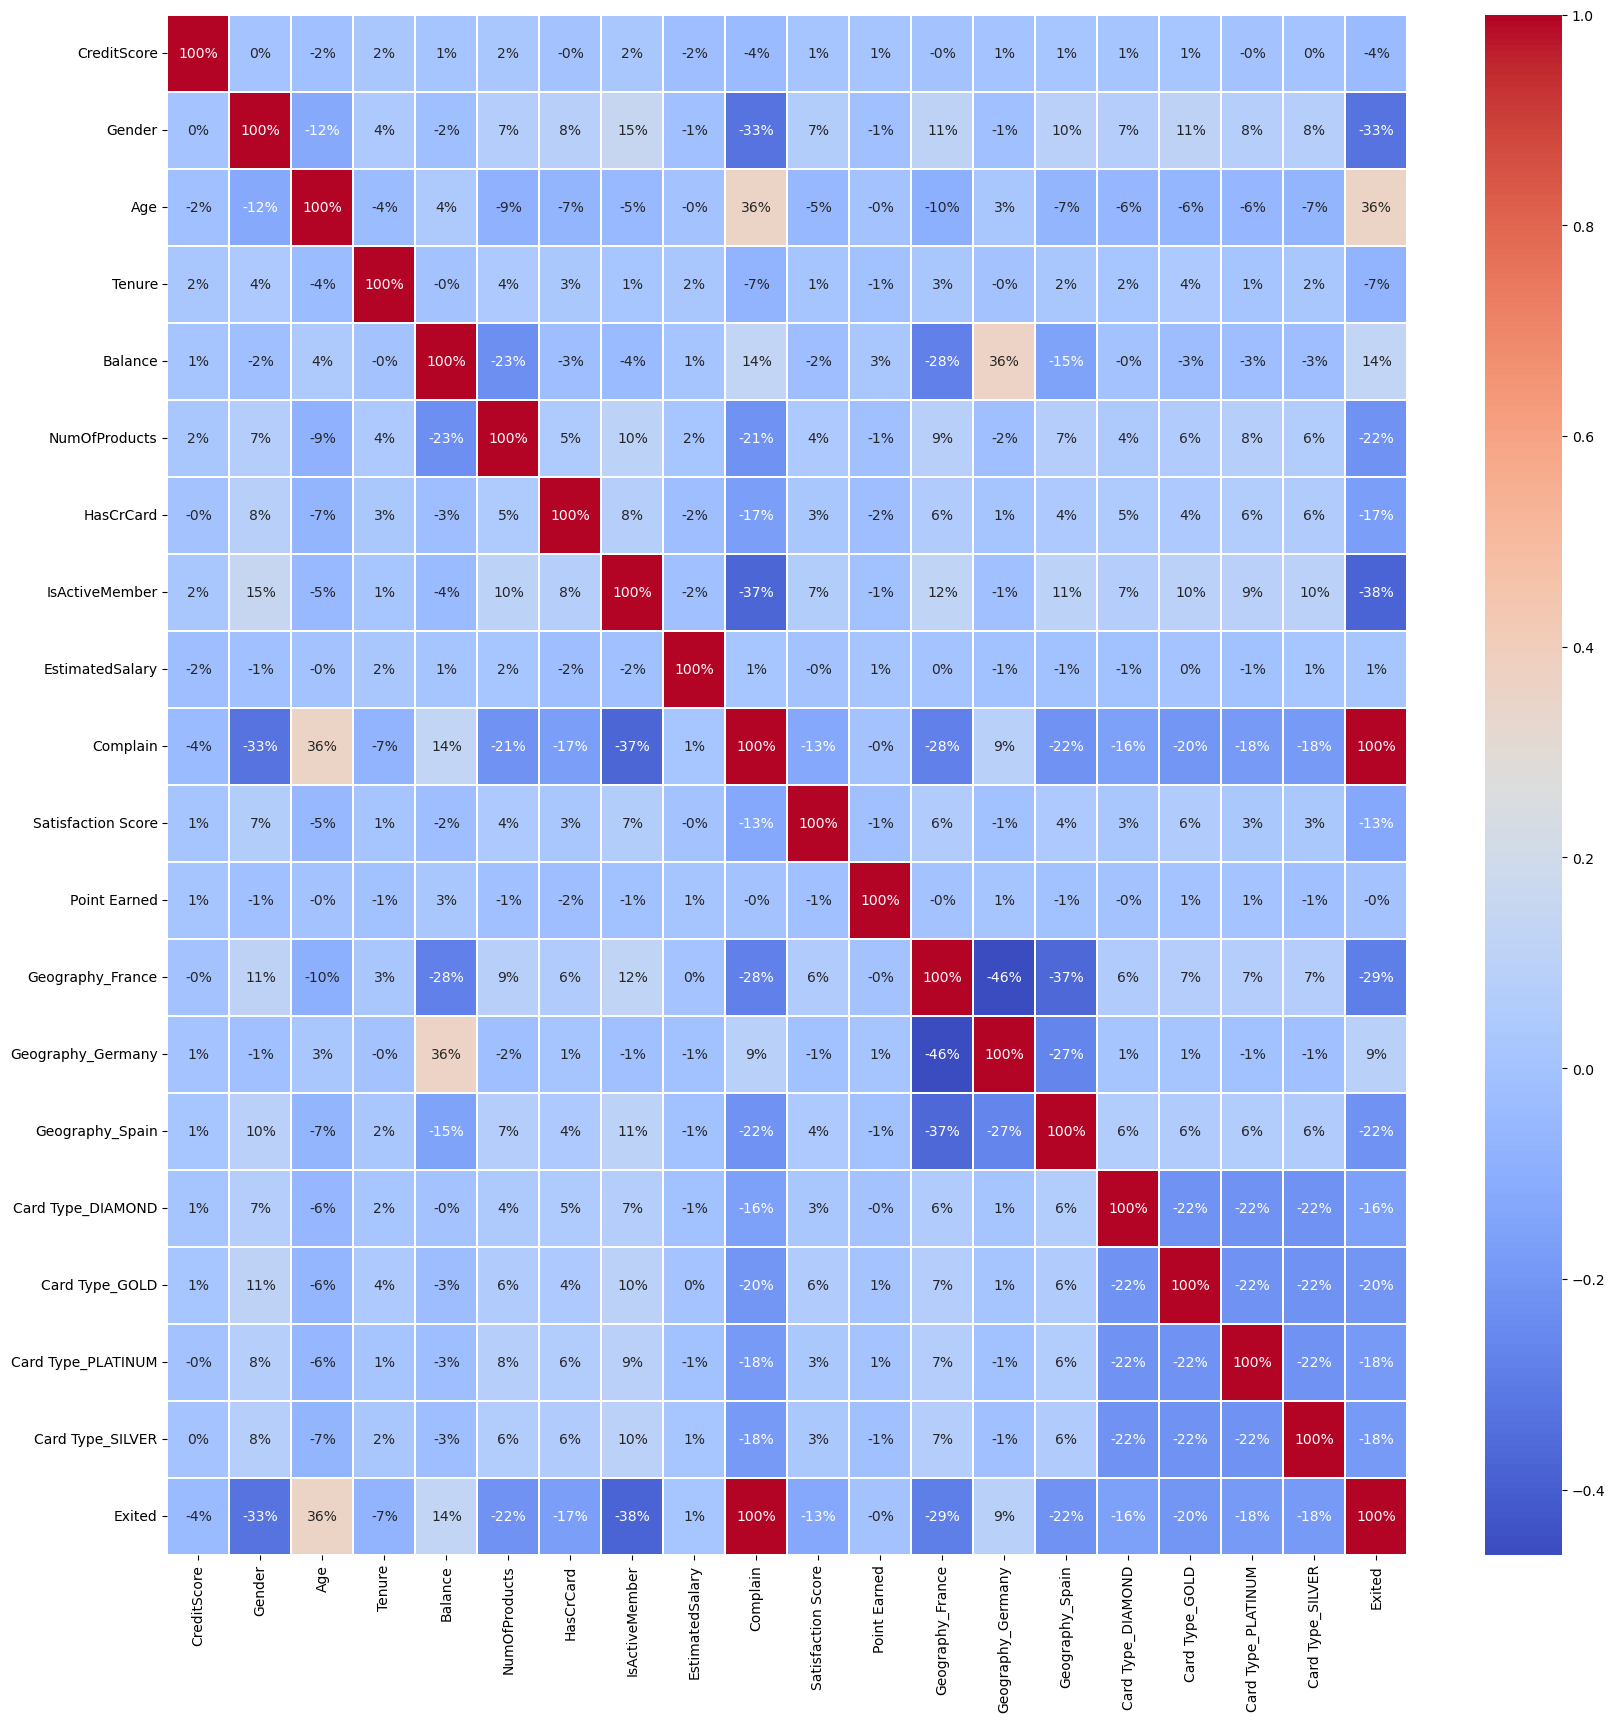

In [24]:
plt.figure(figsize=[20, 20])
sns.heatmap(df2.corr(),
           fmt='.0%',
           annot=True,
           cmap='coolwarm',
           lw=.2)

### ตรวจสอบ Distribution

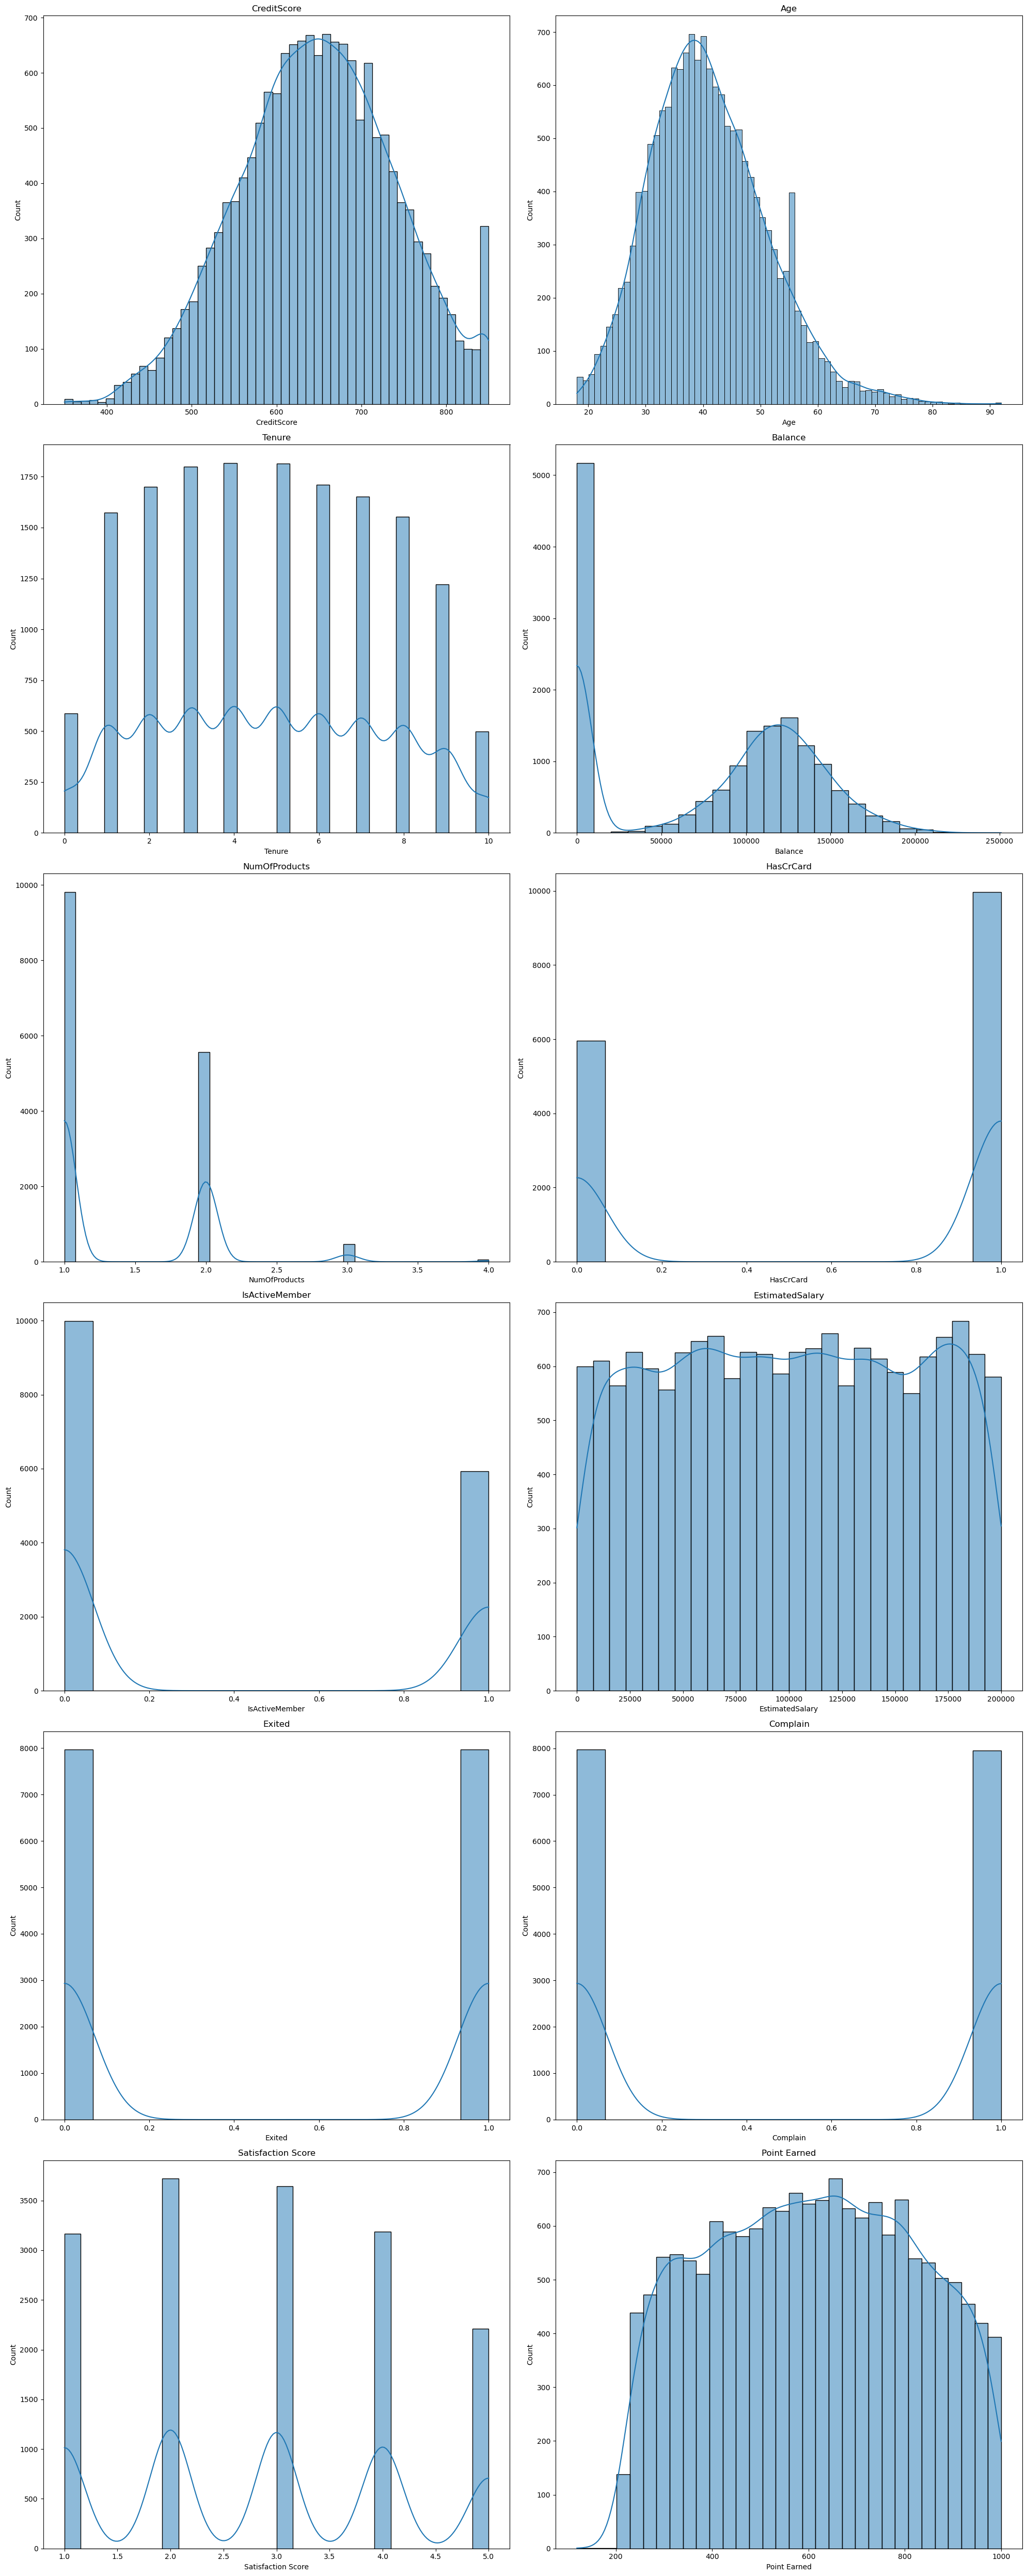

In [25]:
fig, axes = plt.subplots(nrows=6,
                        ncols=2,
                        figsize=[20, 50])
for i, column in enumerate(numerical_col):
    row, col = divmod(i, 2)
    # axes[row, col].hist(df[column])
    sns.histplot(df2[column],
                 ax=axes[row, col],
                 kde=True)
    axes[row, col].set_title(column)
plt.tight_layout()
plt.show()

In [26]:
df2[numerical_col].describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,15924.000000,15924.000000,15924.000000,15924.000000,15924.000000,15924.000000,15924.000000,15924.000000,15924.000000,15924.000000,15924.000000,15924.000000
mean,648.128109,41.009671,4.830884,81122.932684,1.421188,0.625973,0.372331,100497.030667,0.500000,0.499560,2.846333,606.102550
std,91.218563,10.055047,2.721810,61332.932595,0.572019,0.483886,0.483441,57610.771228,0.500016,0.500016,1.326851,211.310814
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,586.000000,34.000000,3.000000,0.000000,1.000000,0.000000,0.000000,51273.849170,0.000000,0.000000,2.000000,430.000000
50%,649.000000,40.000000,5.000000,102872.605000,1.000000,1.000000,0.000000,100718.780000,0.500000,0.000000,3.000000,607.000000
75%,711.000000,47.000000,7.000000,128626.704680,2.000000,1.000000,1.000000,150000.187500,1.000000,1.000000,4.000000,780.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


## ตรวจสอบ Outlier

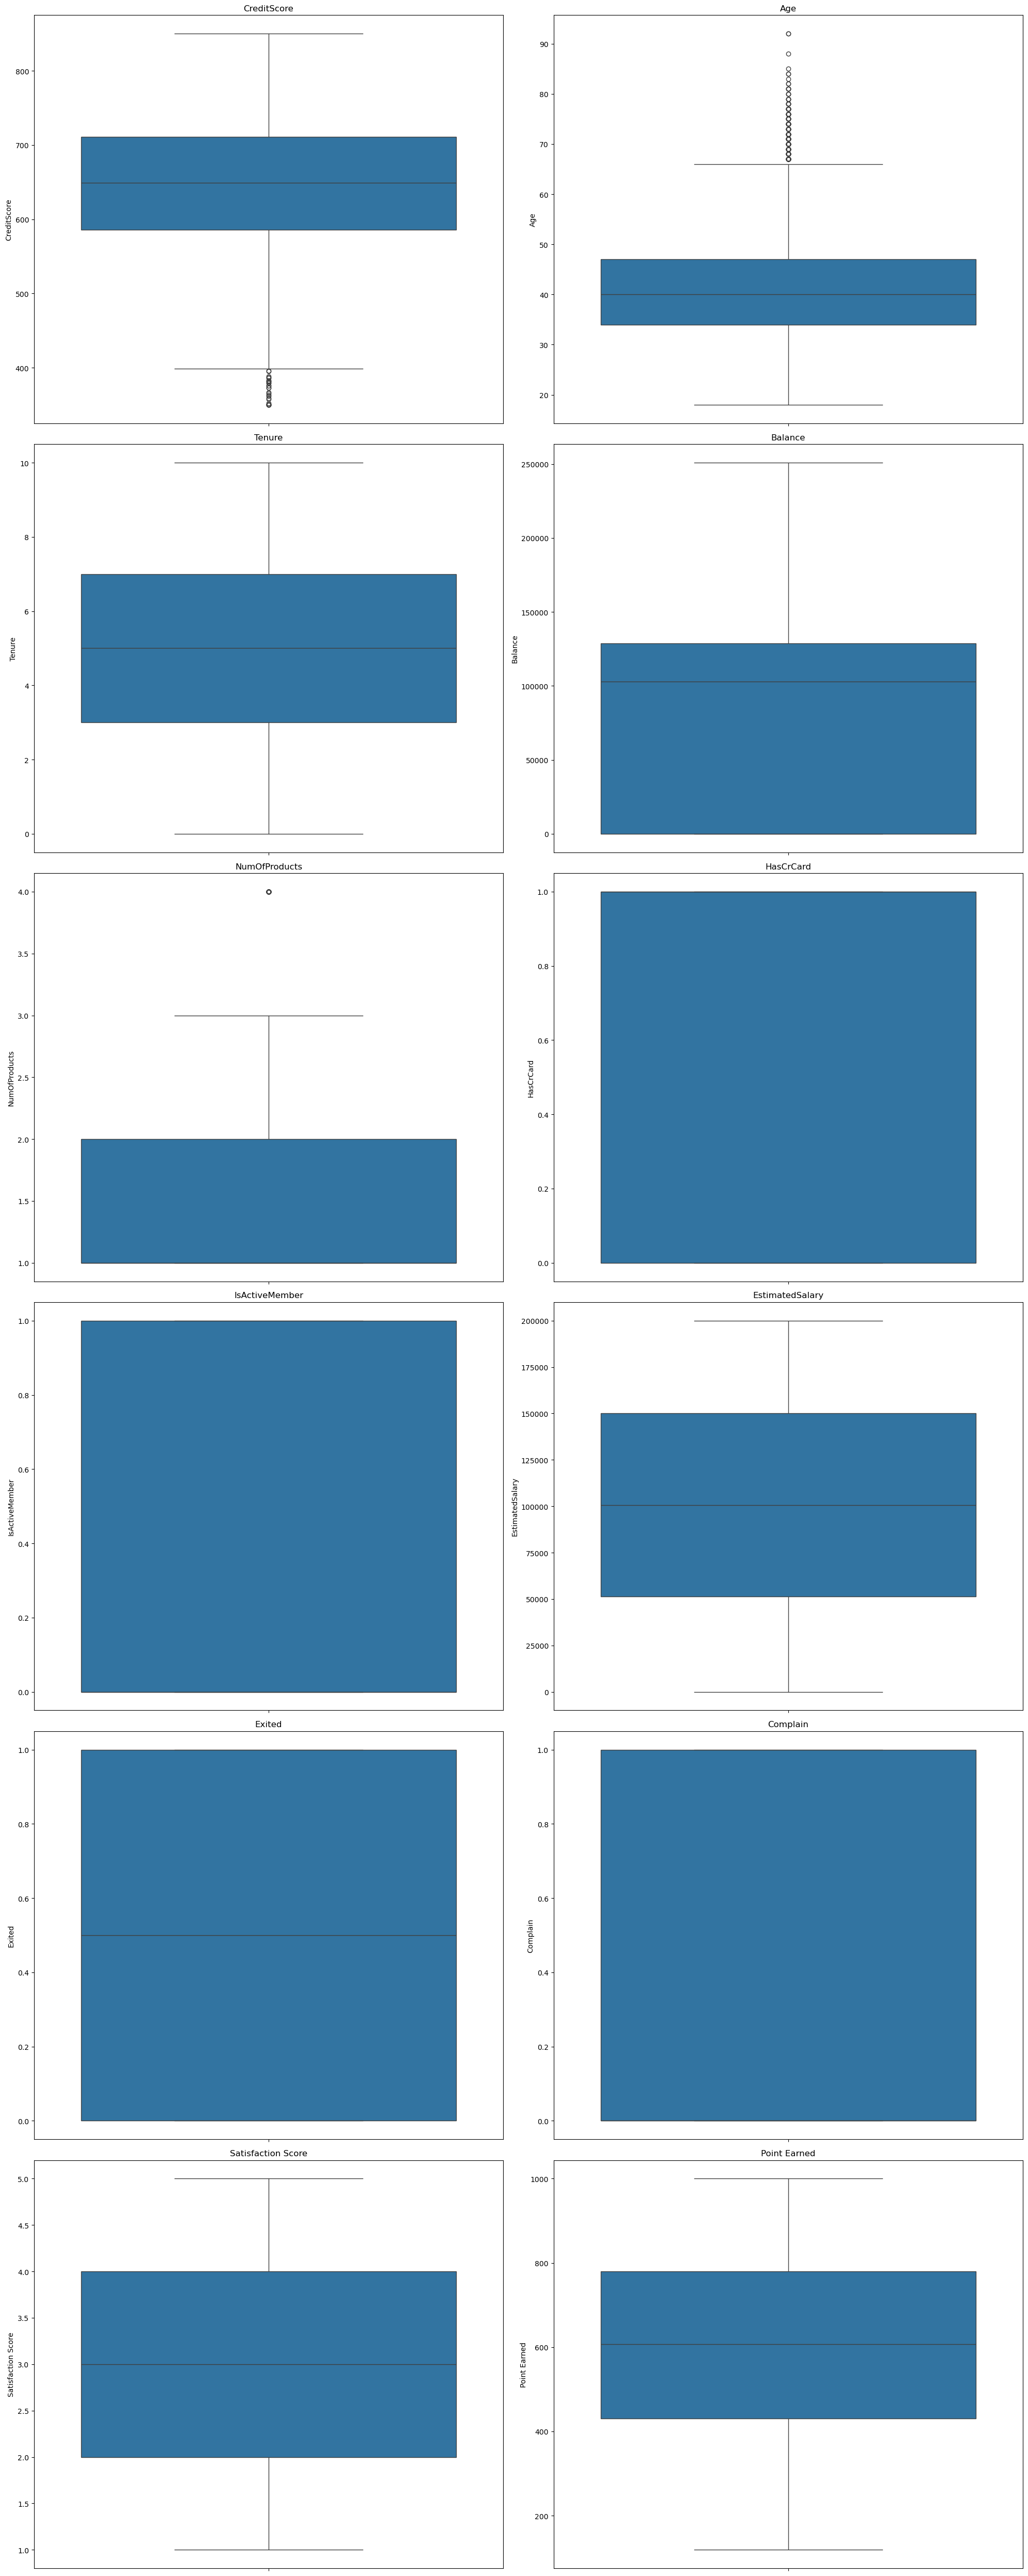

In [27]:
fig, axes = plt.subplots(nrows=6,
                        ncols=2,
                        figsize=[20, 50])
for i, column in enumerate(numerical_col):
    row, col = divmod(i, 2)
    # axes[row, col].hist(df[column])
    sns.boxplot(df2[column],
                 ax=axes[row, col])
    axes[row, col].set_title(column)
plt.tight_layout()
plt.show()

### IQR

In [28]:
outlier_suspect_col = ['CreditScore', 'Age', 'NumOfProducts']
for col in outlier_suspect_col:
    q1 = df[col].quantile(.25)
    q3 = df[col].quantile(.75)
    IQR = q3 - q1
    lower_b = q1 - (IQR * 1.5)
    upper_b = q3 + (IQR * 1.5)
    print(f'{col}:')
    print(f'upper_bond = {upper_b}:')
    print(f'lower_bond = {lower_b}:')
    print('\n')
    

CreditScore:
upper_bond = 919.0:
lower_bond = 383.0:


Age:
upper_bond = 62.0:
lower_bond = 14.0:


NumOfProducts:
upper_bond = 3.5:
lower_bond = -0.5:




## กรอง Outlier

In [29]:
creditscore_condition = ((df2['CreditScore'] >= 383.0) & (df2['CreditScore'] <= 919.0))
age_condition = ((df2['Age'] >= 14.0) & (df2['Age'] <= 62.0))
numofproducts_condition = ((df2['NumOfProducts'] >= -0.5) & (df2['NumOfProducts'] <= 3.5))

In [30]:
df2_no_outlier = df2[
    creditscore_condition & age_condition & numofproducts_condition
]

In [31]:
df2_no_outlier.shape

(15410, 20)

In [32]:
df2_no_outlier['Exited'].value_counts()

Exited
1    7734
0    7676
Name: count, dtype: int64

## แสดง Visualize

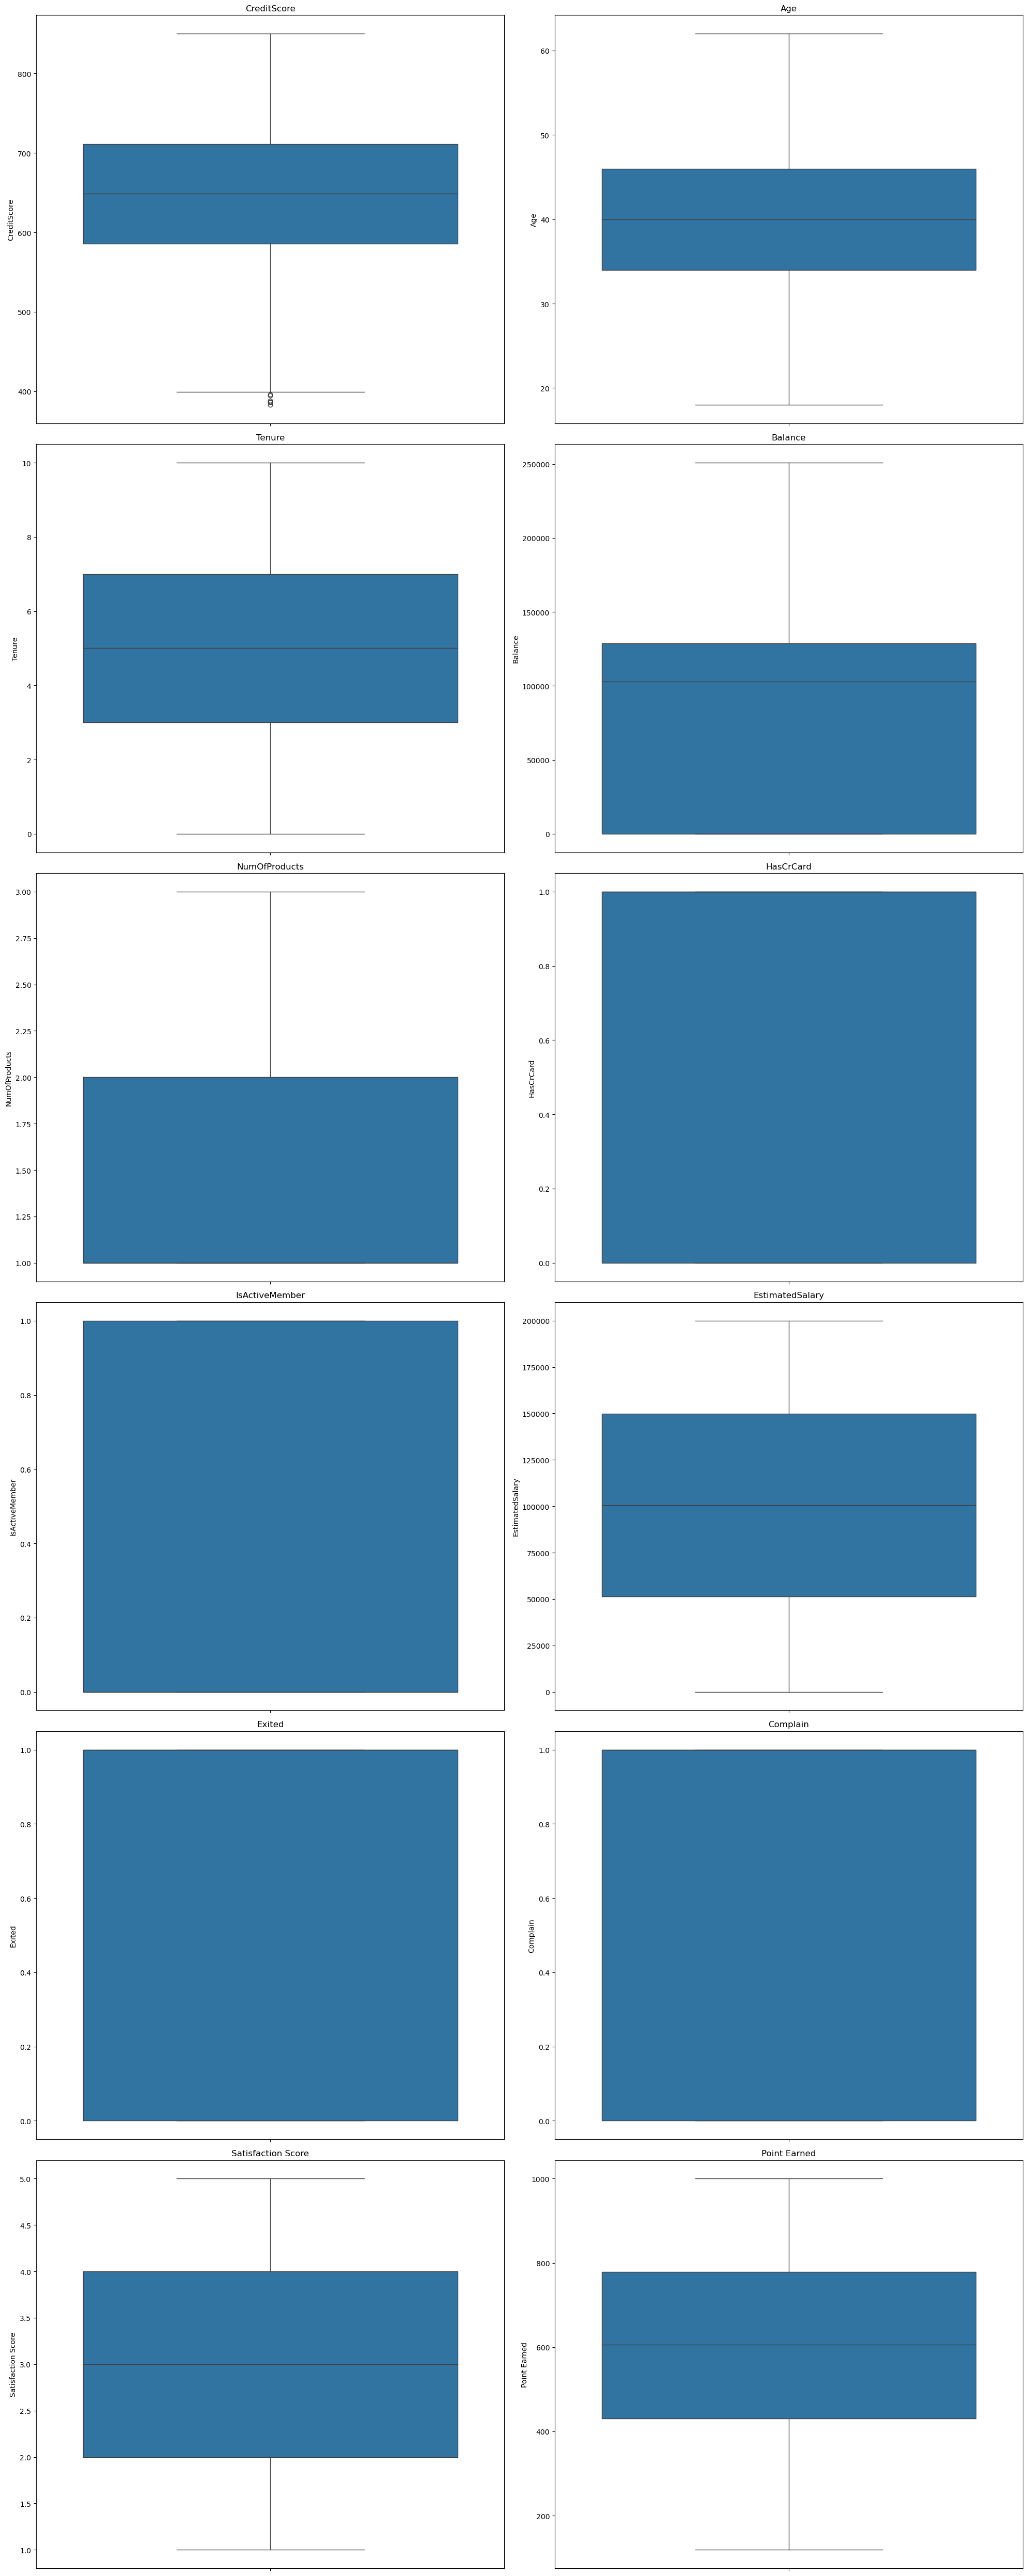

In [33]:
fig, axes = plt.subplots(nrows=6,
                        ncols=2,
                        figsize=[20, 50])
for i, column in enumerate(numerical_col):
    row, col = divmod(i, 2)
    # axes[row, col].hist(df[column])
    sns.boxplot(df2_no_outlier[column],
                 ax=axes[row, col])
    axes[row, col].set_title(column)
plt.tight_layout()
plt.show()

In [34]:
df2_no_outlier.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Point Earned,Geography_France,Geography_Germany,Geography_Spain,Card Type_DIAMOND,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER,Exited
0,619,0,42,2,0.00,1,1,1,101348.88,1,2,464,1,0,0,1,0,0,0,1
1,608,0,41,1,83807.86,1,0,1,112542.58,1,3,456,0,0,1,1,0,0,0,0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,3,377,1,0,0,1,0,0,0,1
3,699,0,39,1,0.00,2,0,0,93826.63,0,5,350,1,0,0,0,1,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,5,425,0,0,1,0,1,0,0,0


# Insight

## ดูช่วงอายุที่ Exited

In [35]:
df2_no_outlier['Age'].describe()

count    15410.000000
mean        40.214276
std          9.012205
min         18.000000
25%         34.000000
50%         40.000000
75%         46.000000
max         62.000000
Name: Age, dtype: float64

In [36]:
bins = [0, 20, 40, 60, 80]  # กำหนดช่วง
labels = ['>=20', '21-40', '41-60', '<=60']  # ชื่อช่วง
df2_no_outlier['Binned-Age'] = pd.cut(df2_no_outlier['Age'],
                                     bins=bins,
                                     labels=labels,
                                     right=True)

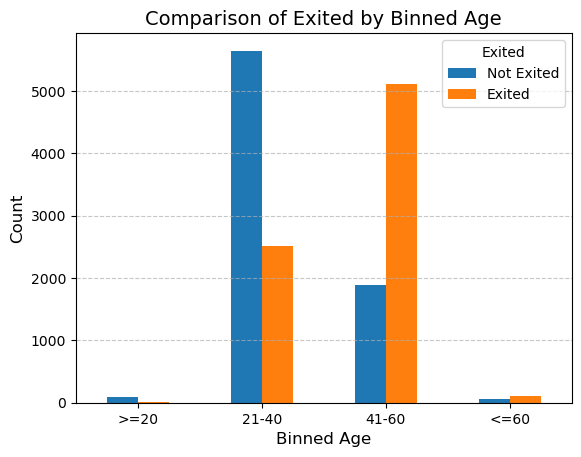

In [37]:
data = df2_no_outlier.groupby(['Binned-Age'])['Exited'].value_counts().unstack()
data.plot(kind='bar', stacked=False)

plt.title("Comparison of Exited by Binned Age", fontsize=14)
plt.xlabel("Binned Age", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(["Not Exited", "Exited"], title="Exited")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)

In [38]:
data

Exited,0,1
Binned-Age,,
>=20,84,11
21-40,5648,2511
41-60,1881,5110
<=60,63,102


## ดูจำนวน 0 , 1 ในแต่ละ geography แยกชายหญิง เป็นกี่%## 

In [39]:
df2_no_outlier["Geography"] = df2_no_outlier[["Geography_Germany", "Geography_Spain", "Geography_France"]].idxmax(axis=1).str.replace("Geography_", "")


In [40]:
df2_no_outlier['Geography']

0         France
1          Spain
2         France
3         France
4          Spain
          ...   
15919     France
15920    Germany
15921    Germany
15922     France
15923    Germany
Name: Geography, Length: 15410, dtype: object

<Axes: xlabel='Geography,Gender'>

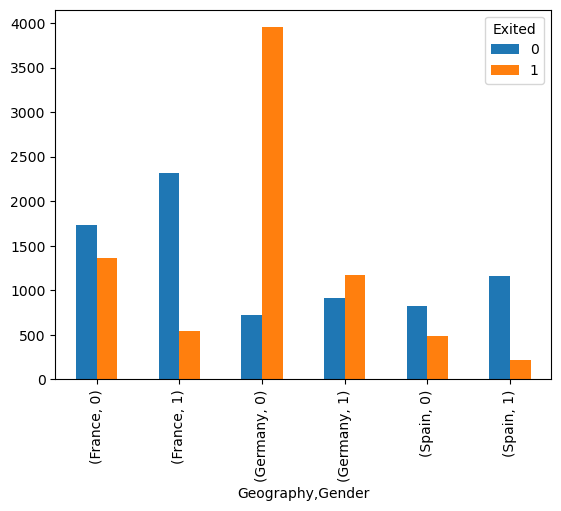

In [41]:
df2_no_outlier.groupby(['Geography', 'Gender', 'Exited'])['Exited'].count().unstack().plot(kind='bar')

In [42]:
df2_no_outlier.groupby(['Geography', 'Gender', 'Exited'])['Exited'].count().unstack()

Exited               0     1
Geography Gender            
France    0       1729  1363
          1       2319   548
Germany   0        726  3953
          1        914  1170
Spain     0        823   485
          1       1165   215

## Pie Chart Churn

### หลัง Oversampling

<Axes: ylabel='count'>

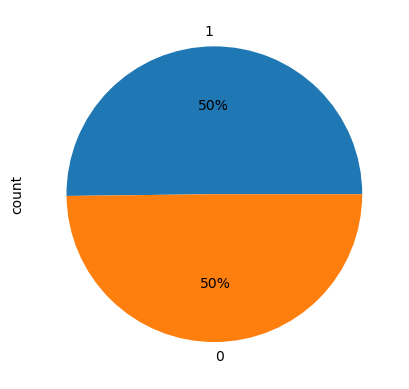

In [43]:
df2_no_outlier['Exited'].value_counts().plot(kind='pie', autopct='%1.0f%%')

### ก่อน Oversampling

<Axes: ylabel='count'>

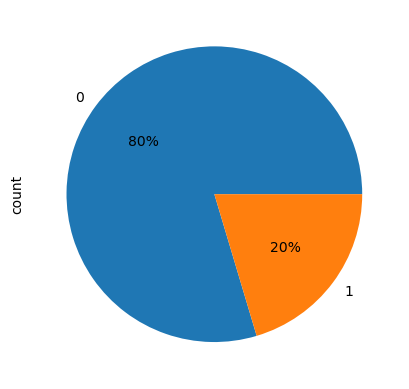

In [44]:
df['Exited'].value_counts().plot(kind='pie', autopct='%1.0f%%')

### ดู geography กับ card type ว่ามีส่วนใดถือมากที่สุด และดูคนออก


In [45]:
df2_no_outlier.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,...,Geography_France,Geography_Germany,Geography_Spain,Card Type_DIAMOND,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER,Exited,Binned-Age,Geography
0,619,0,42,2,0.00,1,1,1,101348.88,1,...,1,0,0,1,0,0,0,1,41-60,France
1,608,0,41,1,83807.86,1,0,1,112542.58,1,...,0,0,1,1,0,0,0,0,41-60,Spain
2,502,0,42,8,159660.80,3,1,0,113931.57,1,...,1,0,0,1,0,0,0,1,41-60,France
3,699,0,39,1,0.00,2,0,0,93826.63,0,...,1,0,0,0,1,0,0,0,21-40,France
4,850,0,43,2,125510.82,1,1,1,79084.10,0,...,0,0,1,0,1,0,0,0,41-60,Spain


In [46]:
df2_no_outlier.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Complain',
       'Satisfaction Score', 'Point Earned', 'Geography_France',
       'Geography_Germany', 'Geography_Spain', 'Card Type_DIAMOND',
       'Card Type_GOLD', 'Card Type_PLATINUM', 'Card Type_SILVER', 'Exited',
       'Binned-Age', 'Geography'],
      dtype='object')

In [47]:
df2_no_outlier["CardType"] = df2_no_outlier[["Card Type_DIAMOND", "Card Type_GOLD", "Card Type_PLATINUM", "Card Type_SILVER"]].idxmax(axis=1).str.replace("Card Type_", "")


In [48]:
df2_no_outlier['CardType']

0         DIAMOND
1         DIAMOND
2         DIAMOND
3            GOLD
4            GOLD
           ...   
15919     DIAMOND
15920     DIAMOND
15921     DIAMOND
15922     DIAMOND
15923    PLATINUM
Name: CardType, Length: 15410, dtype: object

<Axes: xlabel='Geography,CardType'>

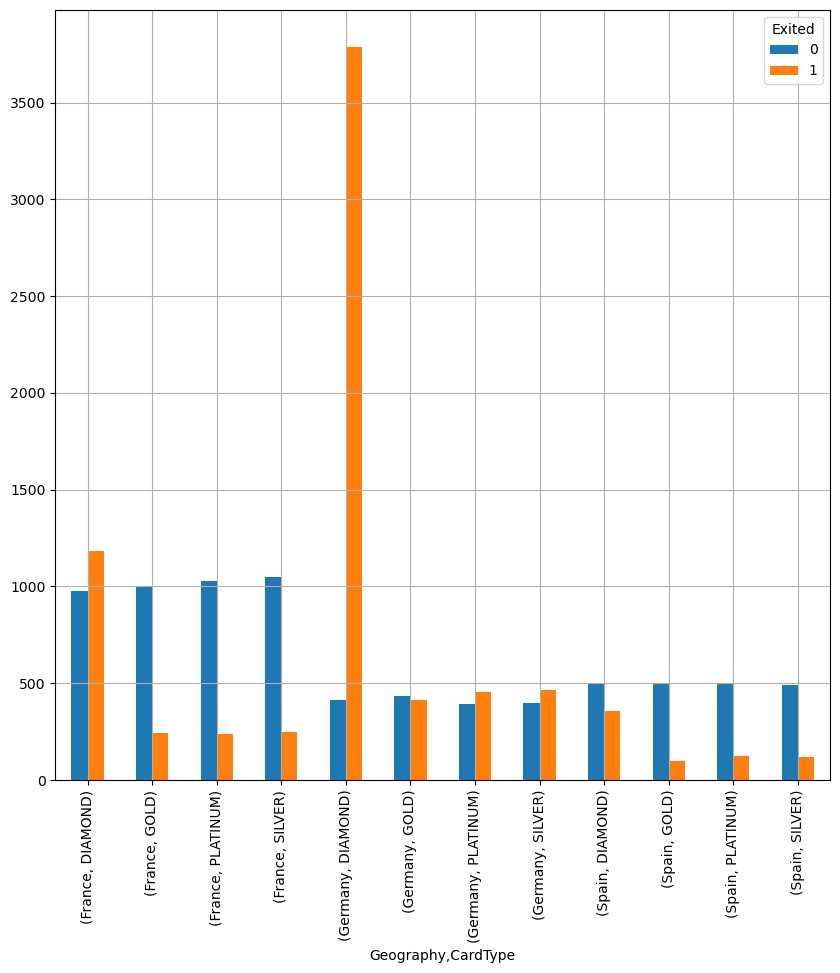

In [49]:
df2_no_outlier.groupby(['Geography', 'CardType', 'Exited'])['Exited'].count().unstack().plot(kind='bar', 
                                                                                             figsize=[10, 10],
                                                                                             grid=True)

### ดู balance กับ NumOfProducts เป็นอย่างไร 

TypeError: enumerate() missing required argument 'iterable'

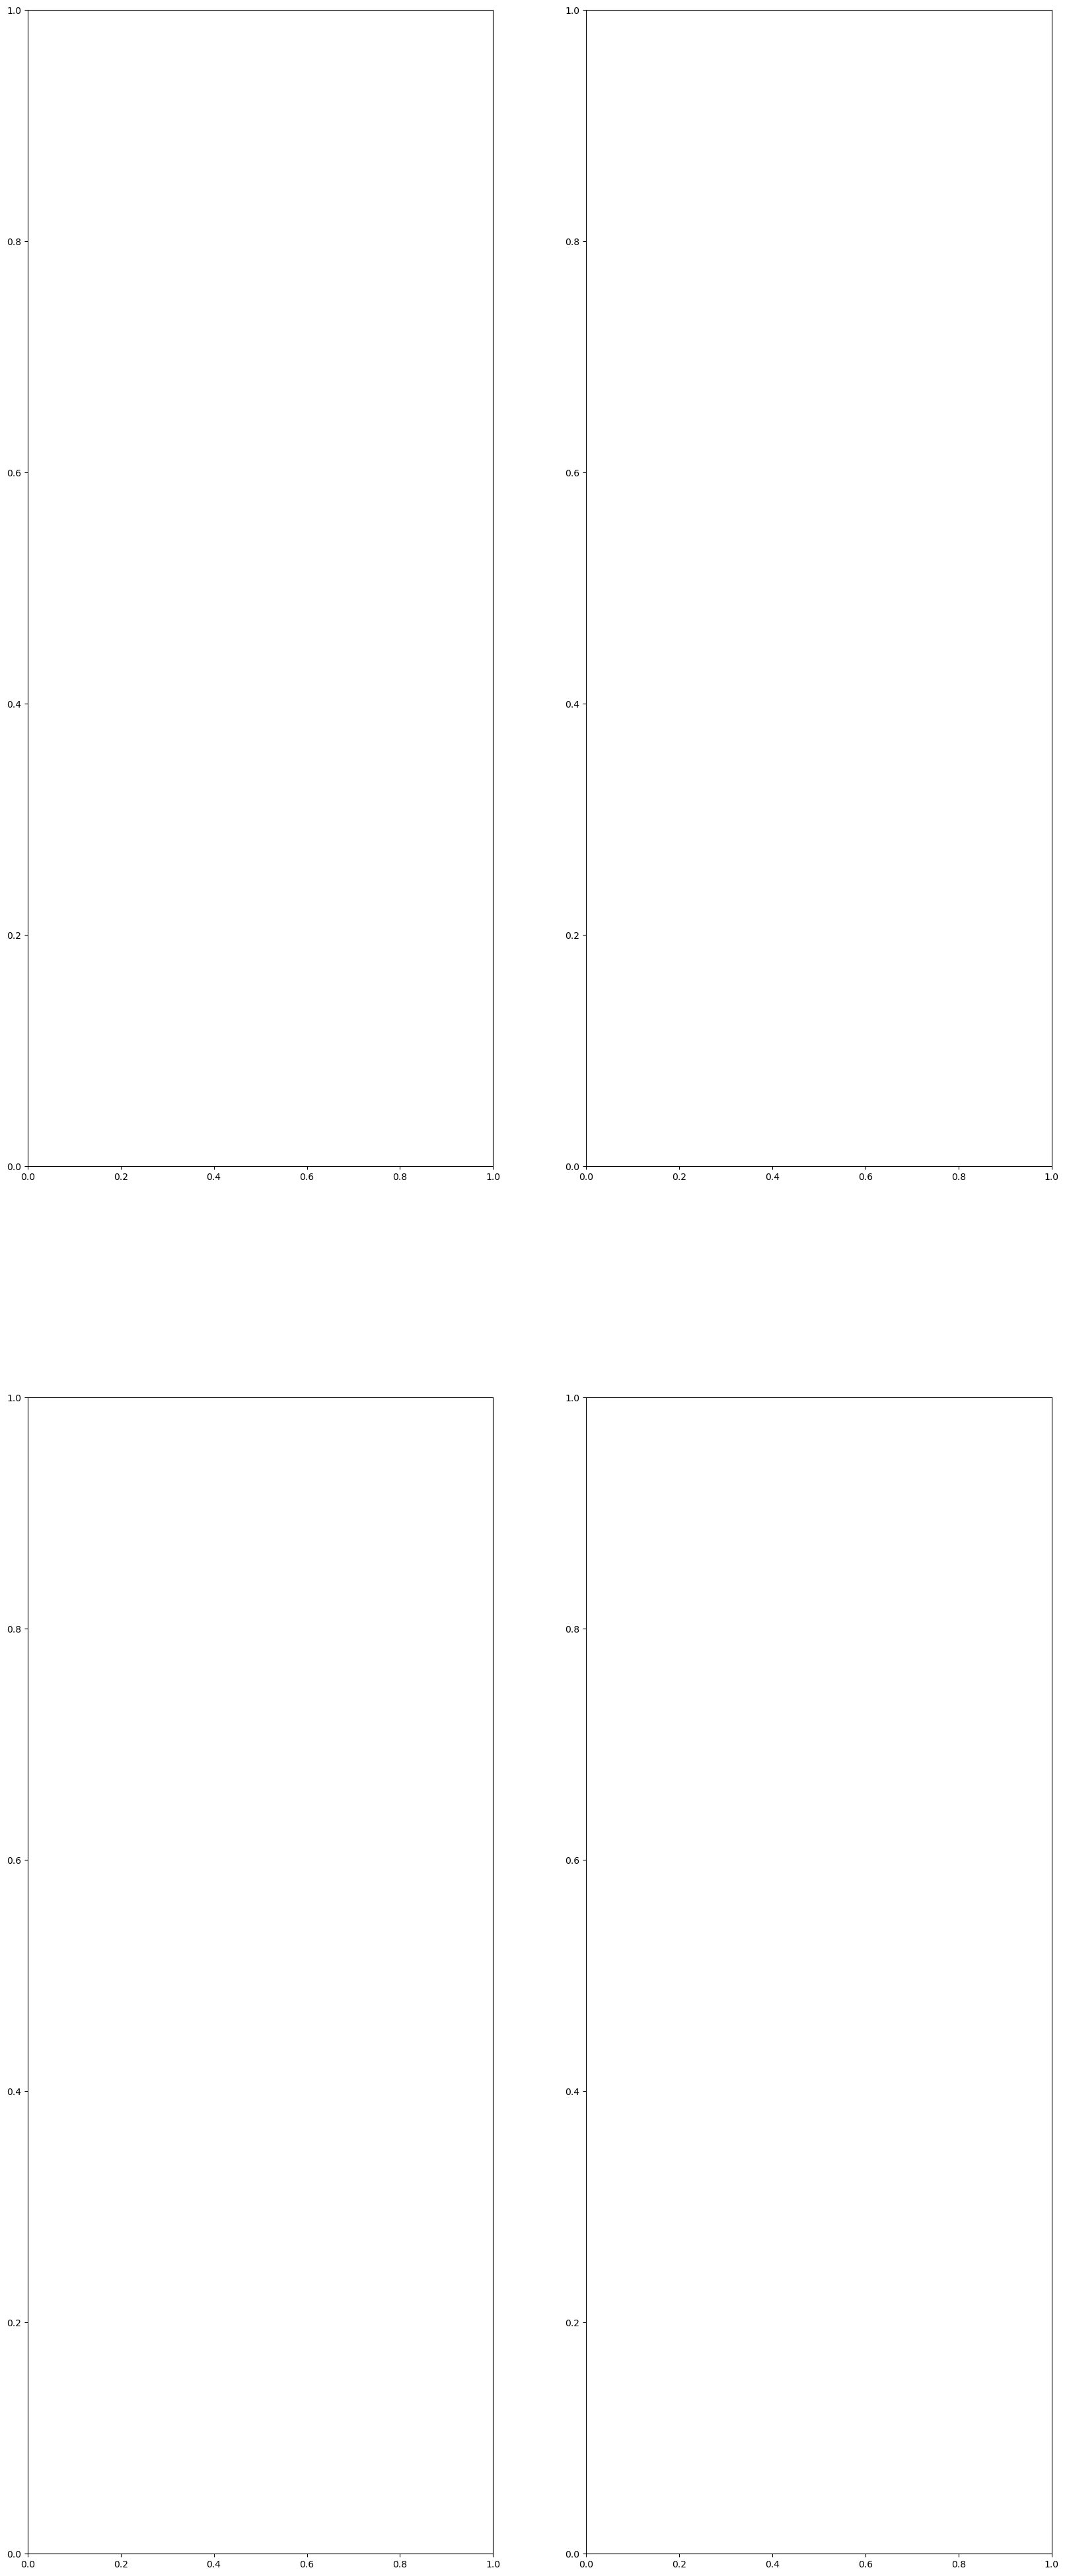

In [50]:
fig, axes = plt.subplots(nrows=2,
                        ncols=2,
                        figsize=[20, 50])
for i, column in enumerate():
    row, col = divmod(i, 2)
    # axes[row, col].hist(df[column])
    data 
    sns.boxplot(df2_no_outlier[column],
                 ax=axes[row, col])
    axes[row, col].set_title(column)
plt.tight_layout()
plt.show()

In [ ]:
df2_no_outlier['NumOfProducts'].unique()

In [ ]:
df2_no_outlier['Balance'][df2_no_outlier['NumOfProducts'] == 1]

In [ ]:
# bins = [0, 20, 40, 60, 80]  # กำหนดช่วง
# labels = ['>=20', '21-40', '41-60', '<=60']  # ชื่อช่วง
# df2_no_outlier['Binned-Age'] = pd.cut(df2_no_outlier['Age'],
#                                      bins=bins,
#                                      labels=labels,
#                                      right=True)

In [ ]:
bins = np.linspace(0, 250000, 11)

In [ ]:
bins

In [ ]:
fig, axes = plt.sub

In [ ]:
df2_no_outlier[['Balance']][df2_no_outlier['NumOfProducts'] == 1].plot(kind='hist', bins=10, )

In [ ]:
df2_no_outlier.groupby(['Complain', 'Exited'])['Exited'].count().unstack().plot(kind='bar')

In [ ]:
df2_no_outlier.groupby(['Tenure', 'Exited'])['Exited'].count().unstack().plot(kind='bar')

In [ ]:
df2_no_outlier.groupby(['Tenure', 'Complain'])['Complain'].count().unstack().plot(kind='bar')

In [ ]:
df2_no_outlier['NumOfProducts']